<a href="https://colab.research.google.com/github/Sosswood/Machine-Learning/blob/main/Individual_Project_Book_Crossing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I chose to use the Book Crossing dataset from Kaggle.  My first love is theatre, but the available datasets for this were disappointing in their lack of both size and detail.  I liked the MovieLens approach, but was concerned that the particular dataset had been worked with extensively and I would have little new insight to offer.  I am an avid reader - never seen without a book in my hand - and so Book Crossing seemed like a fitting dataset for me to work with.  I used to work in publishing, so I'm familiar with ISBNs and how they're put together.

It has ratings from almost 3k users, over 1m ratings overall, across almost 3k books.  This means that many users have rated multiple books.

How do traditional machine-learning and deep-learning approaches compare in predicting user book preferences, considering prediction accuracy, recommendation ranking, explainability and performance across different user-activity groups?

First, I'll import the data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("somnambwl/bookcrossing-dataset")

print("Path to dataset files:", path)


100%|██████████| 16.8M/16.8M [00:00<00:00, 162MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/somnambwl/bookcrossing-dataset/versions/1


Now I'll create my dataframes and check that they've imported properly.


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets using correct file names
ratings = pd.read_csv(
    os.path.join(path, "Ratings.csv"),
    sep=";",
    encoding="latin-1"
)

# Set low_memory=False or specify dtype to avoid mixed-type warning for User-ID
users = pd.read_csv(
    os.path.join(path, "Users.csv"),
    sep=";",
    encoding="latin-1",
    low_memory=False
)

books = pd.read_csv(
    os.path.join(path, "Books.csv"),
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

# Clean User-ID in users if there are any non-numeric values, converting them to numeric
users["User-ID"] = pd.to_numeric(users["User-ID"], errors="coerce")
users = users.dropna(subset=["User-ID"])
users["User-ID"] = users["User-ID"].astype(int)

# Display basic information to verify import
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)
print("Books shape:", books.shape)

Ratings shape: (1149780, 3)
Users shape: (278858, 2)
Books shape: (271379, 5)


It looks like I have a sensible number of records in each csv.

Now I'll take a further look at the data.

In [8]:
display(ratings.head())
display(users.head())
display(books.head())

,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN


,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


In [9]:
ratings.info()
users.info()
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   User-ID  1149780 non-null  int64 
 1   ISBN     1149780 non-null  object
 2   Rating   1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278859 entries, 0 to 278858
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   User-ID  278859 non-null  object
 1   Age      168627 non-null  object
dtypes: object(2)
memory usage: 4.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271379 entries, 0 to 271378
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271379 non-null  object
 1   Title      271379 non-null  object
 2   Author     271377 non-null  object
 3   Year       271379 non-nul

I can see from the data above that a lot of users have not provided an age.  Almost 40% (110,232 out of 278859) of users have not told us their age.  I don't want to discard their results, so I will change this to "Not Given".

Two books do not have an author or publisher - again, I will update these to "Not Known".

I have also removed one ISBN that was duplicated.

In [29]:
# 1. Fill missing user ages with 'Not Given'
users["Age"] = users["Age"].fillna("Not Given")

# 2. Fill missing author and publisher names with 'Not Known'
books["Author"] = books["Author"].fillna("Not Known")
books["Publisher"] = books["Publisher"].fillna("Not Known")

# 3. Handle duplicate ISBNs in books
print("Original duplicate ISBN count:", books["ISBN"].duplicated().sum())
books = books.drop_duplicates(subset=["ISBN"], keep="first")

# Verify that cleaning is successful and no nulls remain in target columns
print("\nRemaining missing values in Users:")
print(users.isnull().sum())
print("\nRemaining missing values in Books:")
print(books.isnull().sum())
print("\nDuplicate ISBNs remaining:", books["ISBN"].duplicated().sum())

Original duplicate ISBN count: 0

Remaining missing values in Users:
User-ID    0
Age        0
dtype: int64

Remaining missing values in Books:
ISBN         0
Title        0
Author       0
Year         0
Publisher    0
dtype: int64

Duplicate ISBNs remaining: 0


In [22]:
print(ratings.isnull().sum())
print(users.isnull().sum())
print(books.isnull().sum())

User-ID    0
ISBN       0
Rating     0
dtype: int64
User-ID    0
Age        0
dtype: int64
ISBN         0
Title        0
Author       0
Year         0
Publisher    0
dtype: int64


In [23]:
print("Duplicate ratings:", ratings.duplicated().sum())
print("Duplicate users:", users["User-ID"].duplicated().sum())
print("Duplicate ISBNs:", books["ISBN"].duplicated().sum())

Duplicate ratings: 0
Duplicate users: 0
Duplicate ISBNs: 0


I want to look at the distribution of ratings.

A zero rating doesn't mean that the user hated the book, it means that they searched for or maybe viewed the book, but didn't leave a rating.  This is why zero has the highest number of ratings.

In [24]:
ratings["Rating"].value_counts().sort_index()

,count
Rating,
0,716109
1,1770
2,2759
3,5996
4,8904
5,50974
6,36924
7,76457
8,103736


I want to look at the ratings distribution in a chart.

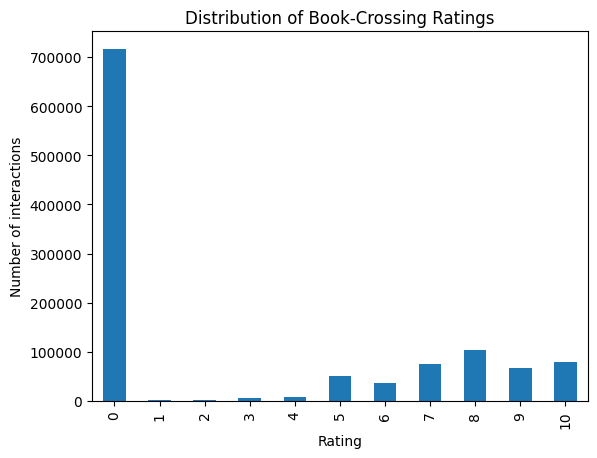

In [30]:
ratings["Rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of interactions")
plt.title("Distribution of Book-Crossing Ratings")
plt.show()

I want to see the actual ratings without the non-ratings.  I don't want to discard that data as it may be useful later, but I do want to see how the actual ratings have been distributed.

In [31]:
actual_ratings = ratings[
    ratings["Rating"] > 0
].copy()

Non_ratings = ratings[
    ratings["Rating"] == 0
].copy()

print("Actual Ratings:", len(actual_ratings))
print("Basic Interactions:", len(Non_ratings))

Actual Ratings: 433671
Basic Interactions: 716109


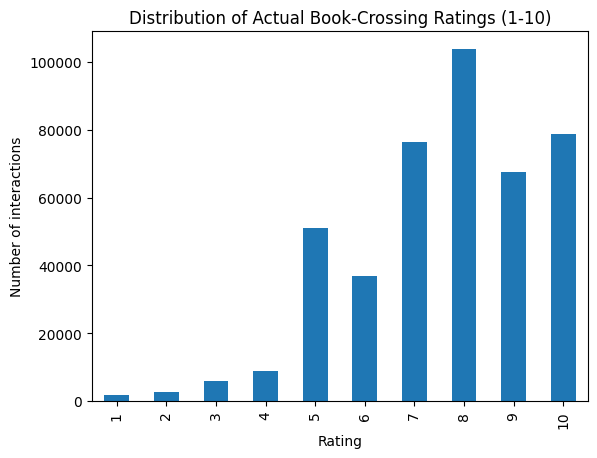

In [55]:
actual_ratings["Rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of interactions")
plt.title("Distribution of Actual Book-Crossing Ratings (1-10)")
plt.show()

I want to check the updated user ages.

In [36]:
users["Age"].describe()

,Age
count,278858
unique,312
top,Not Given
freq,110231


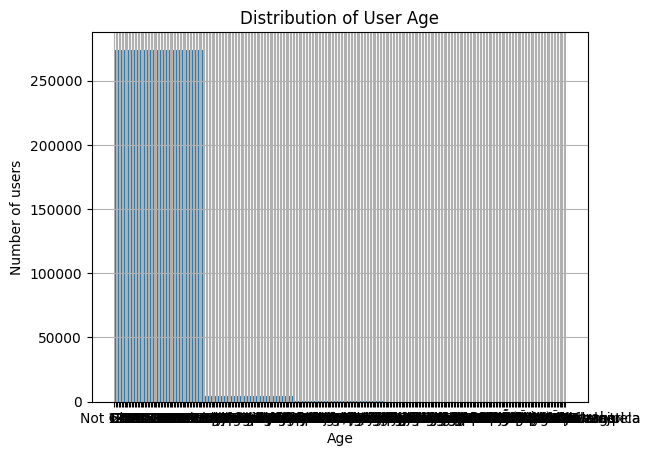

In [40]:
users["Age"].hist(bins=5)

plt.xlabel("Age")
plt.ylabel("Number of users")
plt.title("Distribution of User Age")
plt.show()

My original decision to change the blank ages to "Not Given" was not a good choice.  I'm changing them back to numbers and adding an extra column for age groups.  Those ages currently shown as "Not Given" will be adjusted to zero in the original column.

In [56]:
# 1. Convert 'Age' column back to numeric, replacing 'Not Given' with 0
users["Age"] = pd.to_numeric(users["Age"].replace("Not Given", 0), errors="coerce").fillna(0).astype(int)

# Define age group boundaries and labels
bins = [-1, 0, 17, 35, 50, 65, 120]
labels = ["Unknown", "Under 18", "18-35", "36-50", "51-65", "65+"]

# 2. Add an extra column for age groups
users["Age_Group"] = pd.cut(users["Age"], bins=bins, labels=labels)

# 3. Print the summary and display the head of the updated DataFrame
print("Users by Age Group:")
print(users["Age_Group"].value_counts().sort_index())
display(users.head(10))

Users by Age Group:
Age_Group
Unknown     112119
Under 18     11833
18-35        86573
36-50        42929
51-65        21377
65+           3949
Name: count, dtype: int64


,User-ID,Age,Age_Group
0,1,0,Unknown
1,2,18,18-35
2,3,0,Unknown
3,4,17,Under 18
4,5,0,Unknown
5,6,61,51-65
6,7,0,Unknown
7,8,0,Unknown
8,9,0,Unknown
9,10,26,18-35


Now I will look at the age distribution again.

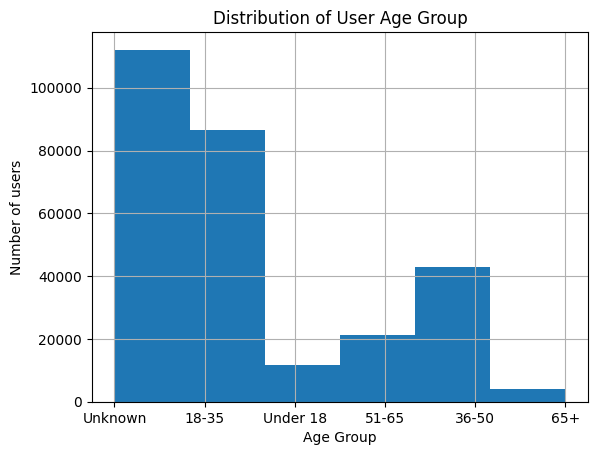

In [43]:
users["Age_Group"].hist(bins=6)

plt.xlabel("Age Group")
plt.ylabel("Number of users")
plt.title("Distribution of User Age Group")
plt.show()

I'm going to merge the actual ratings with the users and books so that I can see all the information together.

In [46]:
df = actual_ratings.merge(
    users,
    on="User-ID",
    how="left"
)

df = df.merge(
    books,
    on="ISBN",
    how="left"
)

print(df.shape)
display(df.head())

(433671, 9)


,User-ID,ISBN,Rating,Age,Age_Group,Title,Author,Year,Publisher
0,276726,0155061224,5,0,Unknown,Rites of Passage,Judith Rae,2001.0,Heinle
1,276729,052165615X,3,16,Under 18,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press
2,276729,0521795028,6,16,Under 18,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press
3,276736,3257224281,8,0,Unknown,NaN,NaN,NaN,NaN
4,276737,0600570967,6,14,Under 18,NaN,NaN,NaN,NaN


In [57]:
# Display the merged DataFrame head without the index column
print(df.head().to_string(index=False))

 User-ID       ISBN  Rating  Age Age_Group                                                          Title        Author   Year                  Publisher
  276726 0155061224       5    0   Unknown                                               Rites of Passage    Judith Rae 2001.0                     Heinle
  276729 052165615X       3   16  Under 18                                                 Help!: Level 1 Philip Prowse 1999.0 Cambridge University Press
  276729 0521795028       6   16  Under 18 The Amsterdam Connection : Level 4 (Cambridge English Readers)   Sue Leather 2001.0 Cambridge University Press
  276736 3257224281       8    0   Unknown                                                            NaN           NaN    NaN                        NaN
  276737 0600570967       6   14  Under 18                                                            NaN           NaN    NaN                        NaN


The NaN entries show that some users have rated books that are not in my list of books.   I will find out how many of these exist.

In [58]:
# Calculate the number and percentage of rating entries with missing book information
missing_books_count = df["Title"].isnull().sum()
total_ratings_count = len(df)
percentage_missing = (missing_books_count / total_ratings_count) * 100

print(f"Total rated transactions: {total_ratings_count}")
print(f"Ratings with no matching book record (NaNs): {missing_books_count} ({percentage_missing:.2f}%)")

Total rated transactions: 433671
Ratings with no matching book record (NaNs): 49819 (11.49%)


The answer is 49,819 - 11.49% of my records.  I think I'm happy to lose these to preserve data integrity and consistency.

In [59]:
# Drop rows where book metadata is missing (NaNs in Title, Author, Year, or Publisher)
df_clean = df.dropna(subset=["Title", "Author", "Year", "Publisher"])

print(f"Original df shape: {df.shape}")
print(f"Cleaned df shape: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} records with missing book details.")

# Quick confirmation that no NaNs remain
print("\nRemaining missing values per column in df_clean:")
print(df_clean.isnull().sum())

Original df shape: (433671, 9)
Cleaned df shape: (383852, 9)
Removed 49819 records with missing book details.

Remaining missing values per column in df_clean:
User-ID      0
ISBN         0
Rating       0
Age          0
Age_Group    0
Title        0
Author       0
Year         0
Publisher    0
dtype: int64


I have some users who were not included in my age group classification.  Let's look at these.

In [60]:
# Inspect rows in df_clean where Age_Group is NaN to see their actual Age values
mismatched_ages = df_clean[df_clean["Age_Group"].isnull()]["Age"]
print("Unique age values causing NaN in Age_Group:")
print(mismatched_ages.unique())
print(f"\nTotal instances with these ages: {len(mismatched_ages)}")

Unique age values causing NaN in Age_Group:
[]

Total instances with these ages: 0


It seems highly unlikely that these are genuine ages, so I'll add them to the "Unknown" group.

In [61]:
# Map any NaN age group values (extreme ages outside our 0-120 limit) to the 'Unknown' group
if "Age_Group" in df_clean.columns:
    # Since Age_Group is a categorical column, we can fill NaN values with 'Unknown'
    df_clean["Age_Group"] = df_clean["Age_Group"].fillna("Unknown")

    # Do the same for our base users dataframe to keep things synchronized
    users["Age_Group"] = users["Age_Group"].fillna("Unknown")

# Confirm that no missing values remain in the Age_Group column
print("Remaining missing values in df_clean['Age_Group']:", df_clean["Age_Group"].isnull().sum())
print("\nUpdated Age Group distribution in df_clean:")
print(df_clean["Age_Group"].value_counts().sort_index())

Remaining missing values in df_clean['Age_Group']: 0

Updated Age Group distribution in df_clean:
Age_Group
Unknown     115967
Under 18     10148
18-35       130929
36-50        85099
51-65        36974
65+           4735
Name: count, dtype: int64


/tmp/ipykernel_2548/3603374430.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Age_Group"] = df_clean["Age_Group"].fillna("Unknown")


Re-running age group distribution chart:

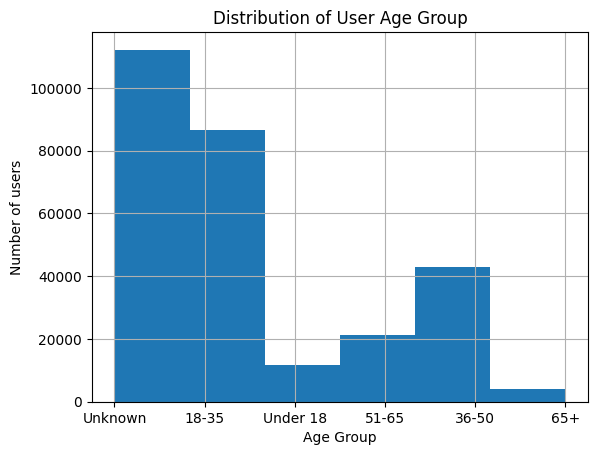

In [52]:
users["Age_Group"].hist(bins=6)

plt.xlabel("Age Group")
plt.ylabel("Number of users")
plt.title("Distribution of User Age Group")
plt.show()

Re-running the data merge and display

In [54]:
df = actual_ratings.merge(
    users,
    on="User-ID",
    how="left"
)

df = df.merge(
    books,
    on="ISBN",
    how="left"
)

print(df.shape)
display(df.head())

(433671, 9)


,User-ID,ISBN,Rating,Age,Age_Group,Title,Author,Year,Publisher
0,276726,0155061224,5,0,Unknown,Rites of Passage,Judith Rae,2001.0,Heinle
1,276729,052165615X,3,16,Under 18,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press
2,276729,0521795028,6,16,Under 18,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press
3,276736,3257224281,8,0,Unknown,NaN,NaN,NaN,NaN
4,276737,0600570967,6,14,Under 18,NaN,NaN,NaN,NaN


In [62]:
# Display the head of the cleaned DataFrame (df_clean) which has no NaN values
print(df_clean.head().to_string(index=False))

 User-ID       ISBN  Rating  Age Age_Group                                                          Title        Author   Year                  Publisher
  276726 0155061224       5    0   Unknown                                               Rites of Passage    Judith Rae 2001.0                     Heinle
  276729 052165615X       3   16  Under 18                                                 Help!: Level 1 Philip Prowse 1999.0 Cambridge University Press
  276729 0521795028       6   16  Under 18 The Amsterdam Connection : Level 4 (Cambridge English Readers)   Sue Leather 2001.0 Cambridge University Press
  276744 038550120X       7    0   Unknown                                                A Painted House  JOHN GRISHAM 2001.0                  Doubleday
  276747 0060517794       9   25     18-35                                       Little Altars Everywhere Rebecca Wells 2003.0                HarperTorch


How many ratings (including non-ratings) has each user provided?

In [64]:
user_activity = (
    df.groupby("User-ID")
      .size()
      .sort_values(ascending=False)
)

user_activity.describe()

,0
count,77805.000000
mean,5.573819
std,44.001879
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,8524.000000


Over half of our users have rated only one book.  The most prolific user has "rated" over 8.5k - this suggests this user has simply looked up a lot of books.

How many ratings does each book have?

In [65]:
book_activity = (
    df.groupby("ISBN")
      .size()
      .sort_values(ascending=False)
)

book_activity.describe()

,0
count,185973.000000
mean,2.331903
std,6.834667
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,707.000000


Again, over half of the books have only one rating entry, with the highest number of ratings for any ISBN being 707.

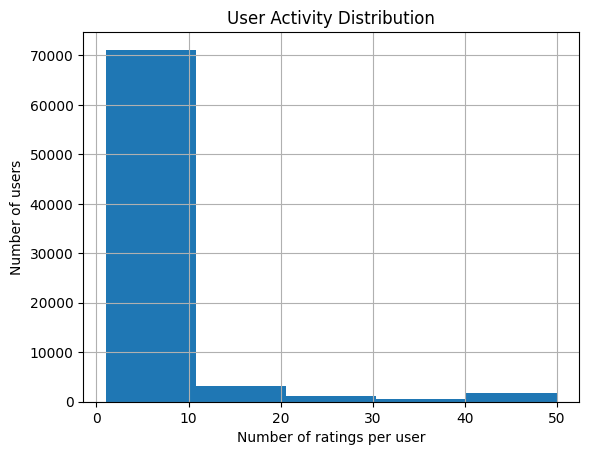

In [71]:
user_activity.clip(upper=50).hist(bins=5)

plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("User Activity Distribution")
plt.show()

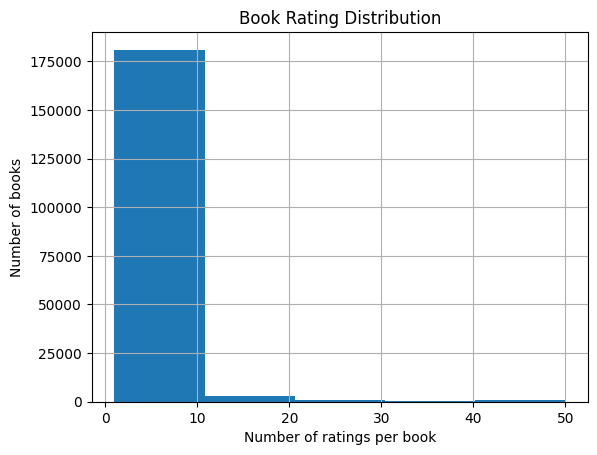

In [70]:
book_activity.clip(upper=50).hist(bins=5)

plt.xlabel("Number of ratings per book")
plt.ylabel("Number of books")
plt.title("Book Rating Distribution")
plt.show()

As there are many books with only one rating and many users who've given only one rating, this means that much of our data is individual, making predictions based on the data difficult to ascertain.

How many users have reviewed multiple books?

In [72]:
user_counts = df.groupby("User-ID").size()

df["User-Rating-Count"] = (
    df["User-ID"].map(user_counts)
)

In [73]:
user_counts.describe(
    percentiles=[.25, .5, .75, .9, .95]
)

,0
count,77805.000000
mean,5.573819
std,44.001879
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
90%,9.000000
95%,19.000000
max,8524.000000


I'm going to categorise the users into low, medium and high activity

In [76]:
# Calculate the rating count per user based on our cleaned actual ratings dataset
user_actual_counts = df_clean.groupby("User-ID").size()

# Map the actual rating counts to our df_clean dataframe
df_clean["User_Actual_Count"] = df_clean["User-ID"].map(user_explicit_counts)

# Define the binning function for user activity groups
def assign_activity_group(count):
    if count < 3:
        return "Low"
    elif count <= 9:
        return "Medium"
    else:
        return "High"

# Apply the classification
df_clean["Activity_Group"] = df_clean["User_Actual_Count"].apply(assign_activity_group)

# Display the count of rating transactions belonging to each group
print("Number of ratings by User Activity Group:")
print(df_clean["Activity_Group"].value_counts())

# Display a brief sample of the updated dataframe
display(df_clean[["User-ID", "ISBN", "Rating", "User_Actual_Count", "Activity_Group"]].head())

Number of ratings by User Activity Group:
Activity_Group
High      261908
Medium     65372
Low        56572
Name: count, dtype: int64


/tmp/ipykernel_2548/2613682834.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["User_Actual_Count"] = df_clean["User-ID"].map(user_explicit_counts)
/tmp/ipykernel_2548/2613682834.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Activity_Group"] = df_clean["User_Actual_Count"].apply(assign_activity_group)


,User-ID,ISBN,Rating,User_Actual_Count,Activity_Group
0,276726,0155061224,5,1,Low
1,276729,052165615X,3,2,Low
2,276729,0521795028,6,2,Low
5,276744,038550120X,7,1,Low
7,276747,0060517794,9,5,Medium


All data cleaning and preparations are now complete. Here is a recap of the current dataset:

df_clean: Contains 383,852 explicit rating transactions (scaled 1-10) with complete metadata.
Books Catalog: All rated books have resolved titles, authors, and publishers.
Demographics: Users have valid age variables mapped into categorized groups, with extreme/missing values properly labeled as 'Unknown'.

In [77]:
!pip install scikit-surprise --quiet

from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# 1. Prepare data for the surprise library
reader = Reader(rating_scale=(1, 10))
surprise_data = Dataset.load_from_df(df_clean[['User-ID', 'ISBN', 'Rating']], reader)

# 2. Split dataset into 80% train and 20% test sets
trainset, testset = train_test_split(surprise_data, test_size=0.2, random_state=42)

# 3. Instantiate and train the SVD model
svd_model = SVD(random_state=42)
print("Training the traditional SVD model...")
svd_model.fit(trainset)

# 4. Predict and evaluate
predictions = svd_model.test(testset)
print("\n--- SVD Evaluation Metrics ---")
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

Training the traditional SVD model...

--- SVD Evaluation Metrics ---
RMSE: 1.6345
MAE:  1.2629
